In [1]:
# STEP 1 - IMPORT LIBRARIES

import pandas as pd
from sqlalchemy import create_engine
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('ggplot')

In [2]:
# STEP 2 - LOAD DATASET

df = pd.read_csv(
    "../data/cleaned/final_engineered_jobs_dataset.csv",
    low_memory=False
)

df.head()

,portal_name,role_search,job_title,company_name,experience_required,salary,location,skills_required,posted_date,job_description,...,jira_flag,jenkins_flag,rest_api_flag,testng_flag,power_apps_flag,total_skills,posting_month,posting_year,jd_length,urgent_hiring_flag
0,Naukri,data-analyst,Data Analyst,Capgemini,4-9 Yrs,NaN,"Hybrid - Chennai, Delhi / NCR, Mumbai (All Areas)","Power Bi, Data Analysis, Data Visualization, T...",2026-05-23 13:19:06.236498,Required Skills & Qualifications: . Bachelors ...,...,0,0,0,0,0,3,May,2026.0,90,0
1,Naukri,data-analyst,Data Analyst,Airtel Payments Bank,2-5 Yrs,NaN,Gurugram,"Power Bi, SQL, Python, Oracle SQL, Quicksight,...",2026-05-17 13:19:06.236498,"Job Description 1- Extract, analyze, and valid...",...,0,0,0,0,0,3,May,2026.0,89,0
2,Naukri,data-analyst,Data Analyst,Sbicap Securities,NaN,10-15 Lacs PA,Mumbai,"Data Analysis, Predictive Modeling, Statistica...",2026-05-17 13:19:06.236498,Key Competencies: . Strong proficiency in Pyth...,...,0,0,0,0,0,2,May,2026.0,90,0
3,Naukri,data-analyst,Data Analyst,Wonderla Holidays,3-5 Yrs,"50,000-80,000 PA",Bengaluru,"D2C, Google Data Studio, R, Google Analytics, ...",2026-05-17 13:19:06.236498,Preferred candidate profile,...,0,0,0,0,0,2,May,2026.0,27,0
4,Naukri,data-analyst,Data Analyst,Snapdeal,1-6 Yrs,NaN,Gurugram,"master data, python, metadata, data analysis, ...",2026-05-03 13:19:06.236498,Providing technical expertise in data storage ...,...,0,0,0,0,0,1,May,2026.0,90,0


In [ ]:
# STEP 3 - CREATE MYSQL CONNECTION

username = "root"

password = "YOUR_PASSWORD"

host = "localhost"

database = "job_market_analysis"

engine = create_engine(
    f"mysql+pymysql://{username}:{password}@{host}/{database}"
)

In [4]:
# STEP 4 - EXPORT DATAFRAME TO MYSQL

df.to_sql(
    name='jobs_data',
    con=engine,
    if_exists='replace',
    index=False
)

print("Data Exported Successfully")

Data Exported Successfully


In [5]:
# STEP 5 - VERIFY TABLE

query = "SELECT * FROM jobs_data LIMIT 5"

pd.read_sql(query, engine)

,portal_name,role_search,job_title,company_name,experience_required,salary,location,skills_required,posted_date,job_description,...,jira_flag,jenkins_flag,rest_api_flag,testng_flag,power_apps_flag,total_skills,posting_month,posting_year,jd_length,urgent_hiring_flag
0,Naukri,data-analyst,Data Analyst,Capgemini,4-9 Yrs,None,"Hybrid - Chennai, Delhi / NCR, Mumbai (All Areas)","Power Bi, Data Analysis, Data Visualization, T...",2026-05-23 13:19:06.236498,Required Skills & Qualifications: . Bachelors ...,...,0,0,0,0,0,3,May,2026.0,90,0
1,Naukri,data-analyst,Data Analyst,Airtel Payments Bank,2-5 Yrs,None,Gurugram,"Power Bi, SQL, Python, Oracle SQL, Quicksight,...",2026-05-17 13:19:06.236498,"Job Description 1- Extract, analyze, and valid...",...,0,0,0,0,0,3,May,2026.0,89,0
2,Naukri,data-analyst,Data Analyst,Sbicap Securities,None,10-15 Lacs PA,Mumbai,"Data Analysis, Predictive Modeling, Statistica...",2026-05-17 13:19:06.236498,Key Competencies: . Strong proficiency in Pyth...,...,0,0,0,0,0,2,May,2026.0,90,0
3,Naukri,data-analyst,Data Analyst,Wonderla Holidays,3-5 Yrs,"50,000-80,000 PA",Bengaluru,"D2C, Google Data Studio, R, Google Analytics, ...",2026-05-17 13:19:06.236498,Preferred candidate profile,...,0,0,0,0,0,2,May,2026.0,27,0
4,Naukri,data-analyst,Data Analyst,Snapdeal,1-6 Yrs,None,Gurugram,"master data, python, metadata, data analysis, ...",2026-05-03 13:19:06.236498,Providing technical expertise in data storage ...,...,0,0,0,0,0,1,May,2026.0,90,0


In [6]:
# STEP 6 - TOTAL JOB COUNT

query = """
SELECT COUNT(*) AS total_jobs
FROM jobs_data;
"""

pd.read_sql(query, engine)

,total_jobs
0,106028


In [7]:
# STEP 7 - PORTAL WISE JOB COUNT

query = """
SELECT
    portal_name,
    COUNT(*) AS total_jobs
FROM jobs_data
GROUP BY portal_name
ORDER BY total_jobs DESC;
"""
portal_df = pd.read_sql(query, engine)

portal_df

,portal_name,total_jobs
0,kaggle_jobs,97682
1,Naukri,7520
2,Foundit,566
3,TimesJobs,190
4,google_jobs,70


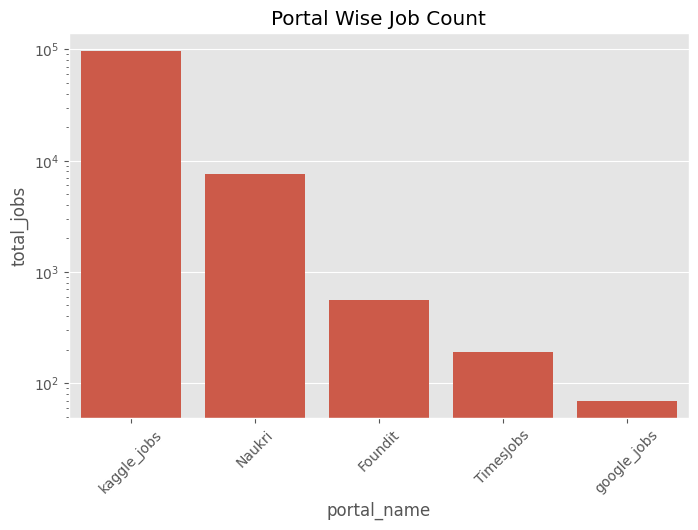

In [8]:
# STEP 7A - PORTAL WISE JOB COUNT VISUALIZATION

plt.figure(figsize=(8,5))

sns.barplot(
    data=portal_df,
    x='portal_name',
    y='total_jobs'
)

plt.yscale('log')

plt.title("Portal Wise Job Count")

plt.xticks(rotation=45)

plt.show()

Insights:

- Kaggle contributes the largest portion of the dataset, while Naukri represents the strongest real-time scraped source.
- Smaller portals like Foundit and TimesJobs provide supplementary market coverage and improve source diversity.

In [9]:
# STEP 8 - TOP HIRING COMPANIES

query = """
SELECT
    company_name,
    COUNT(*) AS total_jobs
FROM jobs_data
GROUP BY company_name
ORDER BY total_jobs DESC
LIMIT 15;
"""

company_df = pd.read_sql(query, engine)

company_df

,company_name,total_jobs
0,Accenture,8796
1,ideslabs private limited,2294
2,Wipro,1523
3,Infosys,1100
4,krazy mantra hr solutions pvt. ltd,1026
5,Kotak Mahindra Bank,984
6,pro hr complete solutions,981
7,Capgemini,808
8,IBM,731
9,EY,630


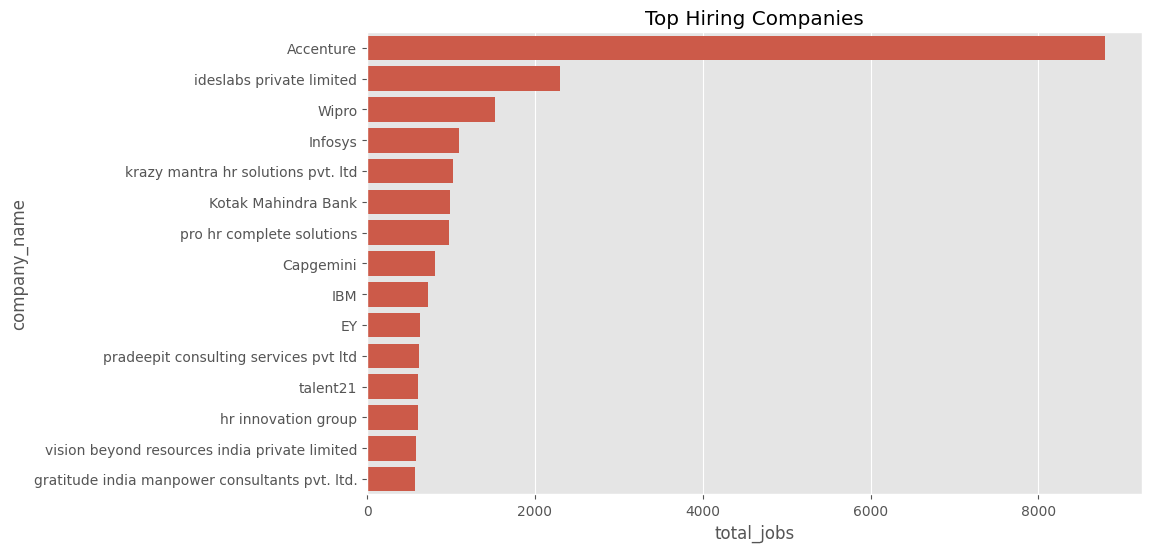

In [10]:
# STEP 8A - TOP HIRING COMPANIES VISUALIZATION

plt.figure(figsize=(10,6))

sns.barplot(
    data=company_df,
    x='total_jobs',
    y='company_name'
)

plt.title("Top Hiring Companies")

plt.show()

Insights:

- A small group of companies contributes a high percentage of job postings, indicating concentrated hiring demand among large organizations and frequent recruiters.

In [11]:
# STEP 9 - TOP JOB LOCATIONS

query = """
SELECT
    location,
    COUNT(*) AS total_jobs
FROM jobs_data
GROUP BY location
ORDER BY total_jobs DESC
LIMIT 15;
"""

location_df = pd.read_sql(query, engine)

location_df

,location,total_jobs
0,Bengaluru,18977
1,Hyderabad,8319
2,Pune,6725
3,Chennai,4812
4,Mumbai,4523
5,Gurugram,4472
6,Noida,2892
7,Remote,2067
8,Ahmedabad,1837
9,Navi Mumbai,1532


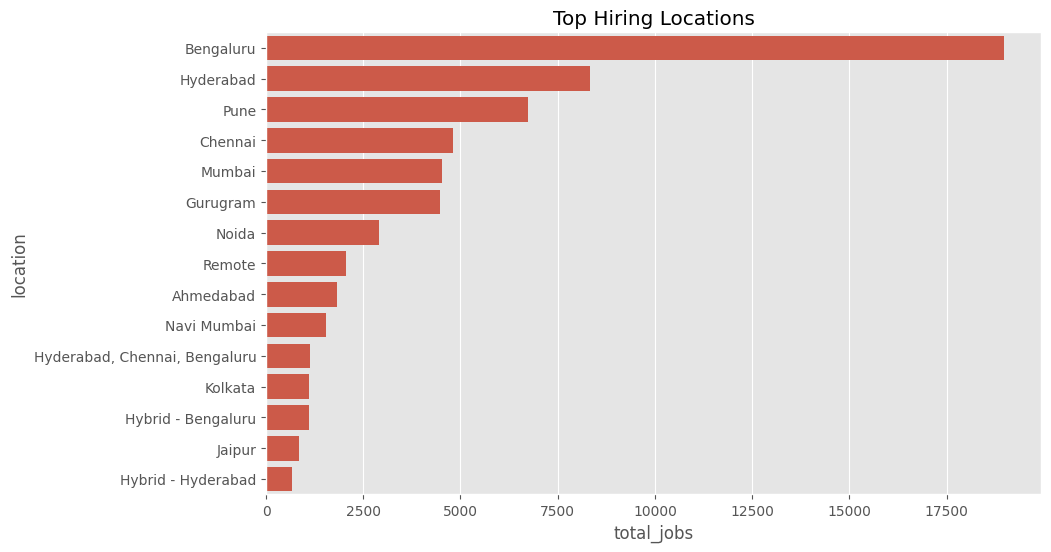

In [12]:
# STEP 9A - TOP JOB LOCATIONS VISUALIZATION

plt.figure(figsize=(10,6))

sns.barplot(
    data=location_df,
    x='total_jobs',
    y='location'
)

plt.title("Top Hiring Locations")

plt.show()

Insights:
- Major metropolitan cities dominate hiring activity, highlighting strong demand in established technology and business hubs across India.

In [13]:
# STEP 10 - TOP JOB ROLES

query = """
SELECT
    job_title,
    COUNT(*) AS total_jobs
FROM jobs_data
GROUP BY job_title
ORDER BY total_jobs DESC
LIMIT 15;
"""

roles_df = pd.read_sql(query, engine)

roles_df

,job_title,total_jobs
0,application developer,2033
1,application lead,1346
2,Data Engineer,668
3,Sales Executive,585
4,Java Developer,543
5,Software Development Engineer,528
6,Business Analyst,496
7,DevOps Engineer,460
8,Business Development Executive,459
9,Project Manager,432


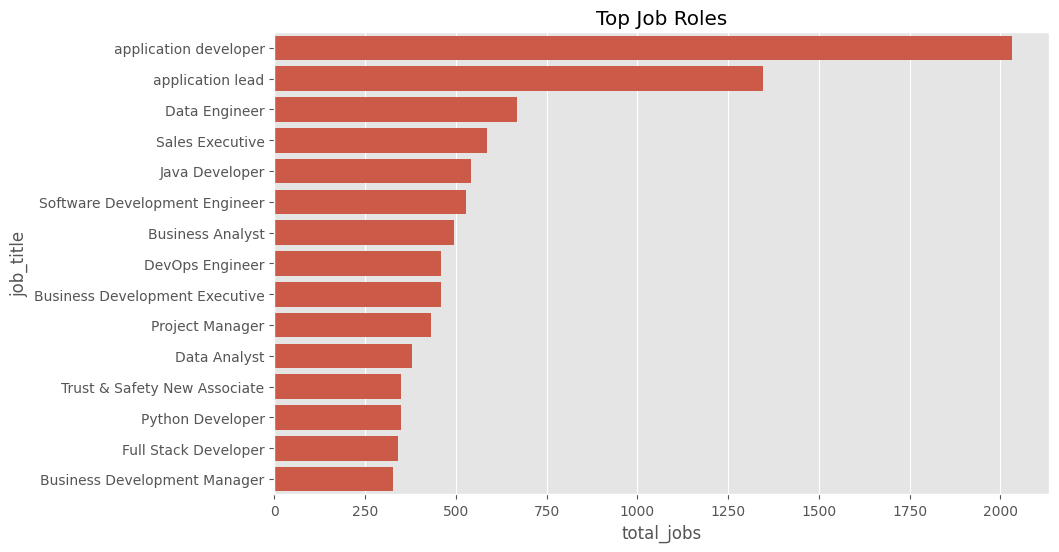

In [14]:
# STEP 10A - TOP JOB ROLES VISUALIZATION

plt.figure(figsize=(10,6))

sns.barplot(
    data=roles_df,
    x='total_jobs',
    y='job_title'
)

plt.title("Top Job Roles")

plt.show()

Insights: 
- Certain job roles appear repeatedly across portals, indicating high market demand and recurring recruitment needs for specific skill sets.

In [15]:
# STEP 11 - AVERAGE COMPANY RATING

query = """
SELECT
    ROUND(AVG(company_rating), 2) AS avg_rating
FROM jobs_data;
"""

pd.read_sql(query, engine)

,avg_rating
0,2.37


Insights:
- Company ratings vary across organizations, but the overall
distribution suggests that most hiring activity is concentrated
among moderately to highly rated companies.

In [16]:
# STEP 12 - EXPERIENCE ANALYSIS

query = """
SELECT
    ROUND(AVG(minimum_experience), 2) AS avg_min_experience,
    ROUND(AVG(maximum_experience), 2) AS avg_max_experience
FROM jobs_data;
"""

experience_df = pd.read_sql(query, engine)

experience_df

,avg_min_experience,avg_max_experience
0,3.94,7.69


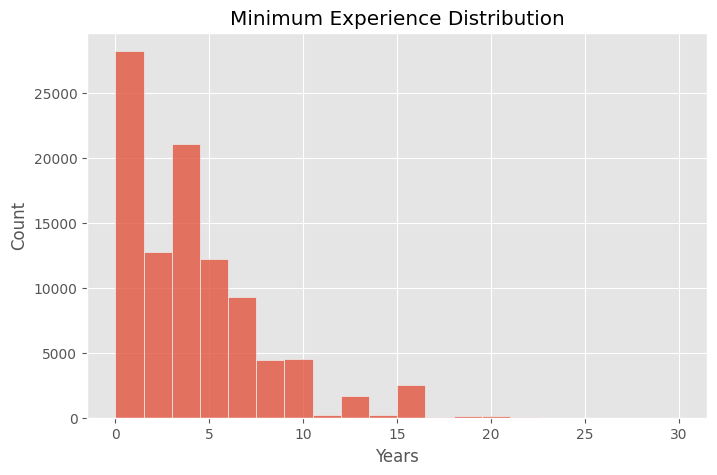

In [17]:
# STEP 12A - EXPERIENCE DISTRIBUTION VISUALIZATION

plt.figure(figsize=(8,5))

sns.histplot(
    df['minimum_experience'].dropna(),
    bins=20
)

plt.title("Minimum Experience Distribution")

plt.xlabel("Years")

plt.show()

Insights:
- Most job openings target early and mid-level professionals,
indicating stronger hiring demand for candidates with moderate
industry experience.

In [18]:
# STEP 13 - MOST REVIEWED COMPANIES

query = """
SELECT
    company_name,
    MAX(reviews_count) AS reviews
FROM jobs_data
GROUP BY company_name
ORDER BY reviews DESC
LIMIT 15;
"""

review_df = pd.read_sql(query, engine)

review_df

,company_name,reviews
0,aparna neo mall,999.0
1,dp world,999.0
2,aparna constructions and estates,999.0
3,sundaram finance (sfl),997.0
4,royal sundaram,997.0
5,sundaram home finance limited (shfl),997.0
6,Mastek,997 Reviews
7,electronica finance,995.0
8,tube investments of india limited (tii),995.0
9,kirloskar brothers limited,995.0


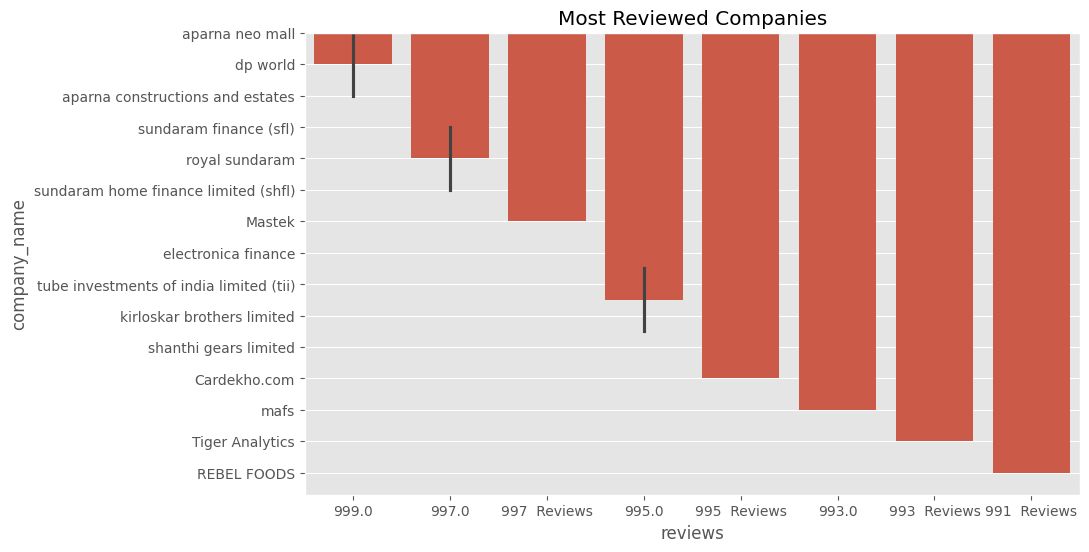

In [19]:
# STEP 13A - MOST REVIEWED COMPANIES VISUALIZATION

plt.figure(figsize=(10,6))

sns.barplot(
    data=review_df,
    x='reviews',
    y='company_name'
)

plt.title("Most Reviewed Companies")

plt.show()

Insights:
- Companies with high review counts are typically large enterprises
with strong market presence and consistent hiring activity.


In [20]:
# STEP 14 - JOBS BY EXPERIENCE LEVEL

query = """
SELECT
    CASE
        WHEN minimum_experience <= 2 THEN 'Entry Level'
        WHEN minimum_experience BETWEEN 3 AND 5 THEN 'Mid Level'
        WHEN minimum_experience BETWEEN 6 AND 10 THEN 'Senior Level'
        ELSE 'Expert Level'
    END AS experience_category,

    COUNT(*) AS total_jobs

FROM jobs_data

GROUP BY experience_category

ORDER BY total_jobs DESC;
"""

exp_category_df = pd.read_sql(query, engine)

exp_category_df

,experience_category,total_jobs
0,Entry Level,41038
1,Mid Level,33313
2,Senior Level,18268
3,Expert Level,13409


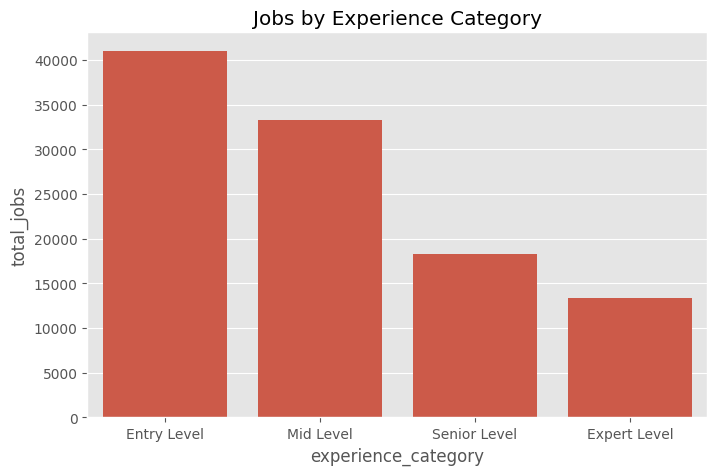

In [21]:
# STEP 14A - EXPERIENCE CATEGORY VISUALIZATION

plt.figure(figsize=(8,5))

sns.barplot(
    data=exp_category_df,
    x='experience_category',
    y='total_jobs'
)

plt.title("Jobs by Experience Category")

plt.show()

Insights:
- Mid-level and senior-level roles contribute significantly to
overall hiring demand, reflecting industry preference for
experienced professionals.

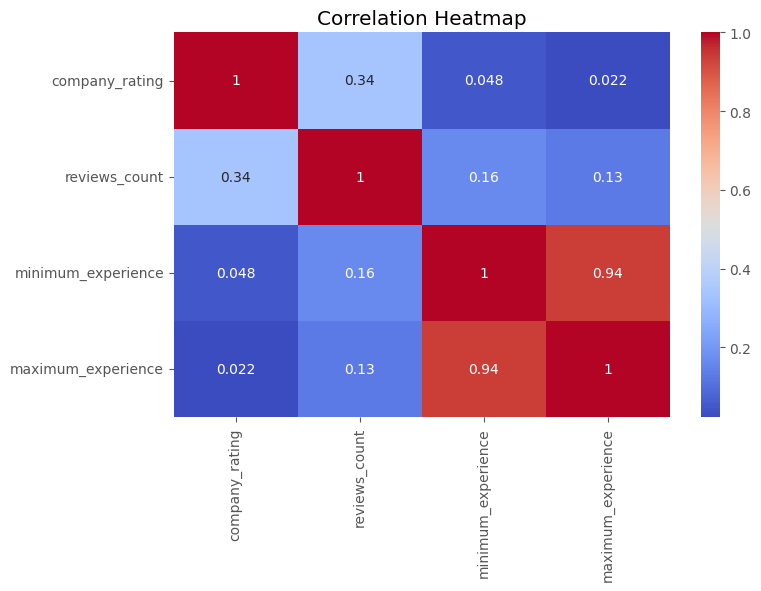

In [22]:
# STEP 15 - CORRELATION HEATMAP

corr_cols = [
    'company_rating',
    'reviews_count',
    'minimum_experience',
    'maximum_experience'
]

for col in corr_cols:
    df[col] = pd.to_numeric(
        df[col],
        errors='coerce'
    )

plt.figure(figsize=(8,5))

corr = df[corr_cols].corr()

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")

plt.show()

Insights:
- Experience-related features show positive correlation,
while company ratings and review counts exhibit weaker
relationships with hiring volume and experience requirements.

In [23]:
# STEP 16 - TOP RATED COMPANIES

query = """
SELECT
    company_name,
    ROUND(AVG(company_rating), 2) AS avg_rating

FROM jobs_data

WHERE company_rating > 0

GROUP BY company_name

HAVING COUNT(*) >= 5

ORDER BY avg_rating DESC

LIMIT 15;
"""

pd.read_sql(query, engine)

,company_name,avg_rating
0,Asky Services Llp,5.0
1,Adhiran Infotech,5.0
2,BHADRA Group,5.0
3,tejas pharma,5.0
4,sharpflux technologies,5.0
5,andt equipment inspection service,5.0
6,culturecord business management solutions,5.0
7,primetrace technologies,5.0
8,swits digital,5.0
9,snow planet,5.0


In [24]:
# STEP 17 - MOST ACTIVE HIRING PORTAL

query = """
SELECT
    portal_name,
    COUNT(*) AS total_jobs

FROM jobs_data

GROUP BY portal_name

ORDER BY total_jobs DESC;
"""

pd.read_sql(query, engine)

,portal_name,total_jobs
0,kaggle_jobs,97682
1,Naukri,7520
2,Foundit,566
3,TimesJobs,190
4,google_jobs,70


Insights:
- Job distribution across portals highlights varying recruitment
strategies, with some platforms focusing on volume-based hiring
while others target niche opportunities.

In [25]:
# STEP 18 - COMPANIES WITH MULTIPLE JOB OPENINGS

query = """
SELECT
    company_name,
    COUNT(*) AS openings

FROM jobs_data

GROUP BY company_name

HAVING openings >= 20

ORDER BY openings DESC;
"""

pd.read_sql(query, engine)

,company_name,openings
0,Accenture,8796
1,ideslabs private limited,2294
2,Wipro,1523
3,Infosys,1100
4,krazy mantra hr solutions pvt. ltd,1026
...,...,...
633,tata consumer products,20
634,"advanced micro devices, inc",20
635,anand systems,20
636,kive consultancy,20


Insights:
- Organizations with large numbers of simultaneous openings may
indicate rapid expansion, large-scale recruitment drives,
or continuous workforce demand.

In [26]:
# STEP 19 - JOBS WITH HIGH EXPERIENCE REQUIREMENT

query = """
SELECT
    job_title,
    company_name,
    minimum_experience,
    maximum_experience

FROM jobs_data

WHERE minimum_experience >= 10

ORDER BY minimum_experience DESC

LIMIT 20;
"""

pd.read_sql(query, engine)

,job_title,company_name,minimum_experience,maximum_experience
0,ceo @ gurugram,careermark6,30.0,31.0
1,"head security operations ( nanded, maharashtra)",slp group,30.0,31.0
2,technical validator,ani integrated services,30.0,31.0
3,junior internal auditor,eurofins,30.0,35.0
4,assistant manager ap,genpact,30.0,31.0
5,manager lean operations,eurofins,30.0,35.0
6,it delivery center head india,eurofins,30.0,35.0
7,"head - business development, discovery services",eurofins,30.0,35.0
8,business consultant retired civil engineer,royal marketing and distributors,29.0,31.0
9,retired human resource advisor,kongovi,28.0,31.0


Insights:
- Highly experienced roles represent specialized positions that
typically require advanced domain expertise and leadership
capabilities.

In [27]:
# STEP 20 - LOCATION WISE HIRING CONCENTRATION

query = """
SELECT
    location,
    COUNT(*) AS total_jobs

FROM jobs_data

WHERE location IS NOT NULL

GROUP BY location

ORDER BY total_jobs DESC

LIMIT 20;
"""

pd.read_sql(query, engine)

,location,total_jobs
0,Bengaluru,18977
1,Hyderabad,8319
2,Pune,6725
3,Chennai,4812
4,Mumbai,4523
5,Gurugram,4472
6,Noida,2892
7,Remote,2067
8,Ahmedabad,1837
9,Navi Mumbai,1532


Insights:
- Hiring concentration remains heavily centered around major
urban regions, emphasizing the continued dominance of
metro cities in employment opportunities.